In [4]:
import numpy as np
import xarray as xr
import dask
import dask.array as da

In [5]:
xr.set_options(display_style="text")

### Create numpy based xarrays

In [28]:
time = np.array([4.453656e09, 4.453656e09])
baseline = np.array([0, 1])
frequency = np.array([1.281331e08, 1.281548e08, 1.281765e08, 1.281982e08])
pol = np.array(["XX", "XY", "YX", "YY"], dtype="<U2")

vis = xr.DataArray(
    np.array(
        [
            [
                [
                    [
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                    ],
                    [
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                    ],
                    [
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                    ],
                    [
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                    ],
                ],
                [
                    [
                        2.4999046e01 - 0.61038834j,
                        6.7443332e-05 - 0.00118741j,
                        -5.8036228e-03 - 0.0012986j,
                        2.2591185e01 - 0.5300595j,
                    ],
                    [
                        2.5040884e01 - 0.6130123j,
                        6.4265958e-05 - 0.0011829j,
                        -5.8168592e-03 - 0.00129384j,
                        2.2631207e01 - 0.5324733j,
                    ],
                    [
                        2.5082985e01 - 0.6156461j,
                        6.1092280e-05 - 0.00117837j,
                        -5.8301669e-03 - 0.00128907j,
                        2.2671568e01 - 0.5348987j,
                    ],
                    [
                        2.5125347e01 - 0.61828965j,
                        5.7922338e-05 - 0.00117383j,
                        -5.8435444e-03 - 0.00128428j,
                        2.2712265e01 - 0.5373354j,
                    ],
                ],
            ],
            [
                [
                    [
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                    ],
                    [
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                    ],
                    [
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                    ],
                    [
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                        0.0000000e00 + 0.0j,
                    ],
                ],
                [
                    [
                        2.5046528e01 - 0.61316466j,
                        -3.5638007e-04 - 0.00116292j,
                        -6.2457677e-03 - 0.0012674j,
                        2.2634113e01 - 0.532508j,
                    ],
                    [
                        2.5088444e01 - 0.6157959j,
                        -3.6030103e-04 - 0.00115835j,
                        -6.2597822e-03 - 0.00126258j,
                        2.2674210e01 - 0.5349287j,
                    ],
                    [
                        2.5130627e01 - 0.61843705j,
                        -3.6422379e-04 - 0.00115377j,
                        -6.2738727e-03 - 0.00125774j,
                        2.2714649e01 - 0.5373609j,
                    ],
                    [
                        2.5173067e01 - 0.62108797j,
                        -3.6814815e-04 - 0.00114917j,
                        -6.2880386e-03 - 0.00125289j,
                        2.2755421e01 - 0.5398045j,
                    ],
                ],
            ],
        ],
        dtype=np.complex64,
    ),
    coords={"time": time, "baseline": baseline, "frequency": frequency, "pol": pol},
    dims=("time", "baseline", "frequency", "pol"),
    attrs={"units": "Jy"},
)

weight = xr.DataArray(
    np.array([[[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]],


       [[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]]], dtype=np.float32),
          coords={"time": time, "baseline": baseline, "frequency": frequency, "pol": pol},
    dims=("time", "baseline", "frequency", "pol"),
)

spatial = np.array(["u", "v", "w"], dtype="<U1")
uvw = xr.DataArray(
    np.array(
        [
            [[0.0, 0.0, 0.0], [59.78163629, 23.1224295, 1.43306931]],
            [[0.0, 0.0, 0.0], [59.78413612, 23.11681138, 1.41935589]],
        ]
    ),
    coords={"time": time, "baseline": baseline, "spatial": spatial},
    dims=("time", "baseline", "spatial"),
    attrs={"units": "m"},
)

ds = xr.Dataset(
    data_vars={
        "vis": vis,
        "weight": weight,
        "uvw": uvw
    },
    coords={
        "time": time,
        "baseline": baseline,
        "frequency": frequency,
        "spatial": spatial
    }
)
ds

<xarray.Dataset> Size: 972B
Dimensions:    (time: 2, baseline: 2, frequency: 4, pol: 4, spatial: 3)
Coordinates:
  * time       (time) float64 16B 4.454e+09 4.454e+09
  * baseline   (baseline) int64 16B 0 1
  * frequency  (frequency) float64 32B 1.281e+08 1.282e+08 1.282e+08 1.282e+08
  * pol        (pol) <U2 32B 'XX' 'XY' 'YX' 'YY'
  * spatial    (spatial) <U1 12B 'u' 'v' 'w'
Data variables:
    vis        (time, baseline, frequency, pol) complex64 512B 0j ... (22.755...
    weight     (time, baseline, frequency, pol) float32 256B 0.0 0.0 ... 1.0 1.0
    uvw        (time, baseline, spatial) float64 96B 0.0 0.0 0.0 ... 23.12 1.419

### Dask arrays

In [8]:
vis_dask = vis.chunk({"frequency": 2})
vis_dask

<xarray.DataArray (time: 2, baseline: 2, frequency: 4, pol: 4)> Size: 512B
dask.array<xarray-<this-array>, shape=(2, 2, 4, 4), dtype=complex64, chunksize=(2, 2, 2, 4), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) float64 16B 4.454e+09 4.454e+09
  * baseline   (baseline) int64 16B 0 1
  * frequency  (frequency) float64 32B 1.281e+08 1.282e+08 1.282e+08 1.282e+08
  * pol        (pol) <U2 32B 'XX' 'XY' 'YX' 'YY'
Attributes:
    units:    Jy

In [9]:
weight_dask = weight.chunk({"frequency": 2})
weight_dask

<xarray.DataArray (time: 2, baseline: 2, frequency: 4, pol: 4)> Size: 256B
dask.array<xarray-<this-array>, shape=(2, 2, 4, 4), dtype=float32, chunksize=(2, 2, 2, 4), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) float64 16B 4.454e+09 4.454e+09
  * baseline   (baseline) int64 16B 0 1
  * frequency  (frequency) float64 32B 1.281e+08 1.282e+08 1.282e+08 1.282e+08
  * pol        (pol) <U2 32B 'XX' 'XY' 'YX' 'YY'

### ufunc functions

In [10]:
def apply_weights_ufunc(vis_arr, weights_arr):
    print("------------ START --------------")
    print("========== FIRST START ==========")
    print(type(vis_arr))
    print(vis_arr.shape)
    # print(vis_arr)
    print("========== FIRST END ============")
    print("========= SECOND START ==========")
    print(type(weights_arr))
    print(weights_arr.shape)
    print(weights_arr)
    print("========= SECOND END ============")
    
    result = np.multiply(vis_arr, weights_arr)
    print("------------  END  --------------")
    return result

### Providing two xarrays with same dimensions

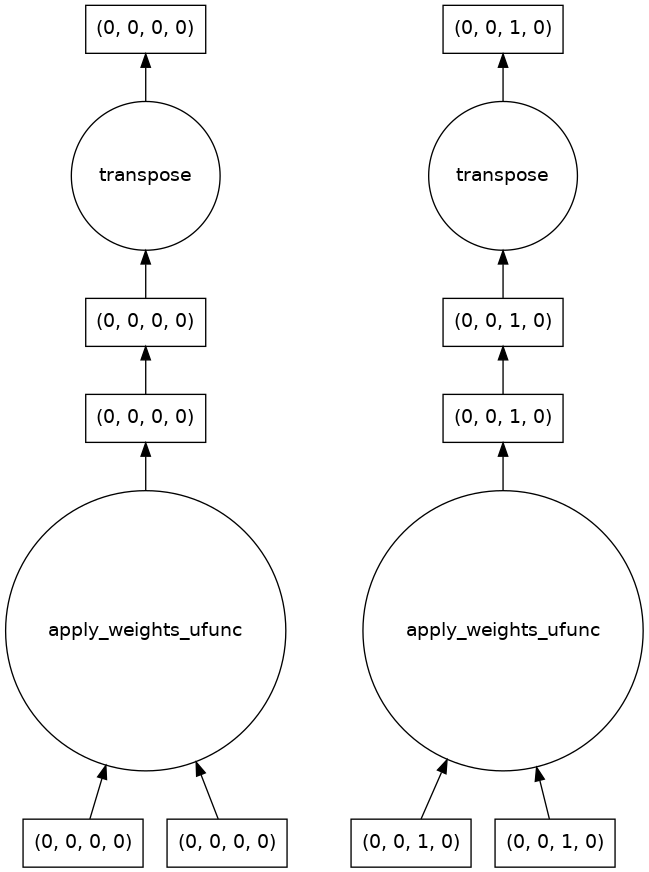

In [7]:
result = xr.apply_ufunc(
    apply_weights_ufunc, 
    vis_dask, weight_dask,
    dask="parallelized",
    output_dtypes=[vis_dask.dtype]
    )

result.data.visualize()

**Observations**
1. custom function gets both arrays data in chunks. 
2. As there are two chunks on frequency dimension for both arrays, custom function gets called two times with chunks.
3. custom function can run parallely.


In [8]:
result.compute()

------------ START --------------
========== FIRST START ==========
<class 'numpy.ndarray'>
(2, 2, 2, 4)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(2, 2, 2, 4)
[[[[0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[1. 1. 1. 1.]
   [1. 1. 1. 1.]]]


 [[[0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[1. 1. 1. 1.]
   [1. 1. 1. 1.]]]]
========= SECOND END ============
------------  END  --------------
------------ START --------------
========== FIRST START ==========
<class 'numpy.ndarray'>
(2, 2, 2, 4)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(2, 2, 2, 4)
[[[[0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[1. 1. 1. 1.]
   [1. 1. 1. 1.]]]


 [[[0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[1. 1. 1. 1.]
   [1. 1. 1. 1.]]]]
========= SECOND END ============
------------  END  --------------


<xarray.DataArray (time: 2, baseline: 2, frequency: 4, pol: 4)> Size: 512B
array([[[[ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ]],

        [[ 2.4999046e+01-0.61038834j,  6.7443332e-05-0.00118741j,
          -5.8036228e-03-0.0012986j ,  2.2591185e+01-0.5300595j ],
         [ 2.5040884e+01-0.6130123j ,  6.4265958e-05-0.0011829j ,
          -5.8168592e-03-0.00129384j,  2.2631207e+01-0.5324733j ],
         [ 2.5082985e+01-0.6156461j ,  6.1092280e-05-0.00117837j,
          -5.8301669e-03-0.00128907j,  2.2671568e+01-0.5348987j ],
         [ 2.5125347e+01-0.61828965j,  5.7922338e-05-0.00117383j,
          -5.8435444e-03-0.00128428j,  2.2712265e+01-0.5373354j ]]],


       [[[ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ]],

        [[ 2.5046528e+01-0.61316466j, -3.5638007e-04-0.00116292j,
          -6.2457677e-03-0.0012674j ,  2.2634113e+01-0.532508j  ],
         [ 2.5088444e+01-0.6157959j , -3.6030103e-04-0.00115835j,
          -6.2597822e-03-0.00126258j,  2.2674210e+01-0.5349287j ],
         [ 2.5130627e+01-0.61843705j, -3.6422379e-04-0.00115377j,
          -6.2738727e-03-0.00125774j,  2.2714649e+01-0.5373609j ],
         [ 2.5173067e+01-0.62108797j, -3.6814815e-04-0.00114917j,
          -6.2880386e-03-0.00125289j,  2.2755421e+01-0.5398045j ]]]],
      dtype=complex64)
Coordinates:
  * time       (time) float64 16B 4.454e+09 4.454e+09
  * baseline   (baseline) int64 16B 0 1
  * frequency  (frequency) float64 32B 1.281e+08 1.282e+08 1.282e+08 1.282e+08
  * pol        (pol) <U2 32B 'XX' 'XY' 'YX' 'YY'

------------ START -------------------------- START --------------
========== FIRST START ==========
<class 'numpy.ndarray'>
(2, 2, 2, 4, 1)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(2, 2, 1, 1, 3)
[[[[[ 0.          0.          0.        ]]]


  [[[59.78163629 23.1224295   1.43306931]]]]



 [[[[ 0.          0.          0.        ]]]


  [[[59.78413612 23.11681138  1.41935589]]]]]
========= SECOND END ============
------------  END  --------------

========== FIRST START ==========
<class 'numpy.ndarray'>
(2, 2, 2, 4, 1)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(2, 2, 1, 1, 3)
[[[[[ 0.          0.          0.        ]]]


  [[[59.78163629 23.1224295   1.43306931]]]]



 [[[[ 0.          0.          0.        ]]]


  [[[59.78413612 23.11681138  1.41935589]]]]]
========= SECOND END ============
------------  END  --------------


## `apply_ufunc` with DataArrays

### Passing xarrays with different dimensions

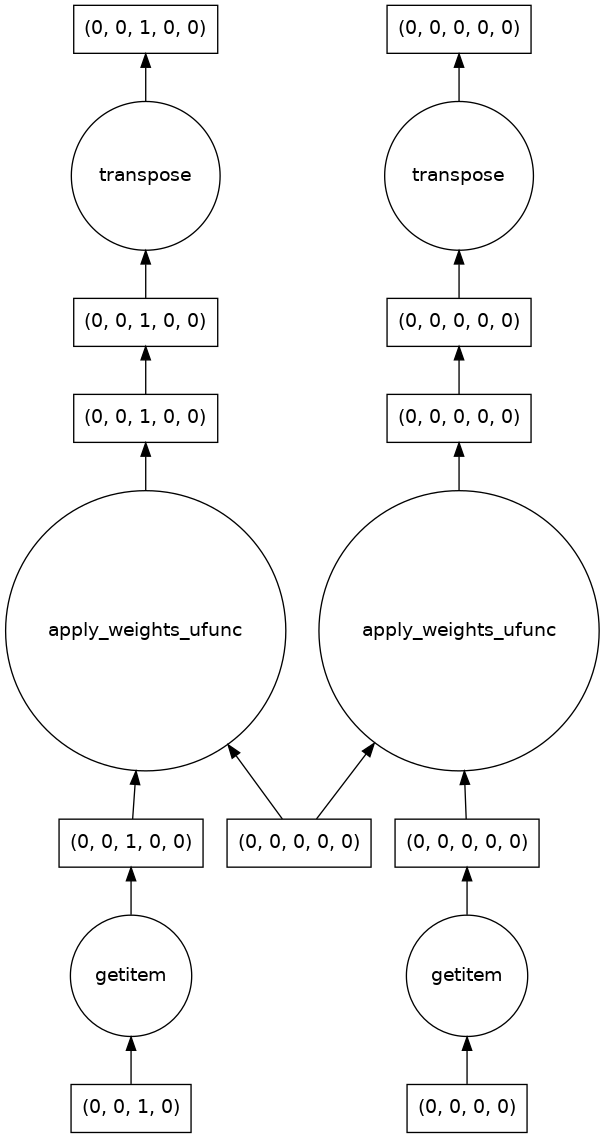

In [7]:
result = xr.apply_ufunc(
    apply_weights_ufunc, 
    vis_dask, uvw,
    dask="parallelized",
    output_dtypes=[vis_dask.dtype]
    )
result.data.visualize()

In [8]:
result.compute()

------------ START --------------
========== FIRST START ==========
<class 'numpy.ndarray'>
(2, 2, 2, 4, 1)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(2, 2, 1, 1, 3)
[[[[[ 0.          0.          0.        ]]]


  [[[59.78163629 23.1224295   1.43306931]]]]



 [[[[ 0.          0.          0.        ]]]


  [[[59.78413612 23.11681138  1.41935589]]]]]
========= SECOND END ============
------------  END  --------------
------------ START --------------
========== FIRST START ==========
<class 'numpy.ndarray'>
(2, 2, 2, 4, 1)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(2, 2, 1, 1, 3)
[[[[[ 0.          0.          0.        ]]]


  [[[59.78163629 23.1224295   1.43306931]]]]



 [[[[ 0.          0.          0.        ]]]


  [[[59.78413612 23.11681138  1.41935589]]]]]
========= SECOND END ============
------------  END  --------------


<xarray.DataArray (time: 2, baseline: 2, frequency: 4, pol: 4, uvw: 3)> Size: 3kB
array([[[[[ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j],
          [ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j],
          [ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j],
          [ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j]],

         [[ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j],
          [ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j],
          [ 0.00000000e+00+0.00000000e+00j,
...
           -5.16963176e-04-1.63761027e-03j],
          [-3.75078059e-01-7.51928970e-02j,
           -1.45031931e-01-2.90749374e-02j,
           -8.90485815e-03-1.78518062e-03j],
          [ 1.35797568e+03-3.21256576e+01j,
            5.25090261e+02-1.24220707e+01j,
            3.22401711e+01-7.62706368e-01j]],

         [[ 1.50495007e+03-3.71312076e+01j,
            5.81921044e+02-1.43575734e+01j,
            3.57295410e+01-8.81544866e-01j],
          [-2.20094189e-02-6.87021348e-02j,
           -8.51041127e-03-2.65651458e-02j,
           -5.22533240e-04-1.63108119e-03j],
          [-3.75924954e-01-7.49029453e-02j,
           -1.45359401e-01-2.89628214e-02j,
           -8.92496458e-03-1.77829678e-03j],
          [ 1.36041317e+03-3.22717468e+01j,
            5.26032768e+02-1.24785592e+01j,
            3.22980404e+01-7.66174722e-01j]]]]])
Coordinates:
  * time       (time) float64 16B 4.454e+09 4.454e+09
  * baseline   (baseline) int64 16B 0 1
  * frequency  (frequency) float64 32B 1.281e+08 1.282e+08 1.282e+08 1.282e+08
  * pol        (pol) <U2 32B 'XX' 'XY' 'YX' 'YY'
  * uvw        (uvw) <U1 12B 'u' 'v' 'w'

**Observations**

As first argument is chunked and second argument not, custom function gets chunk for first array and whole full array for second argument.

### Passing xarrays chunked on different dimensions

In [ ]:
weight_dask_time = weight.chunk({"time": 1})
weight_dask_time.chunksizes

Frozen({'time': (1, 1), 'baseline': (2,), 'frequency': (4,), 'pol': (4,)})

------------ START --------------
========== FIRST START ==========
<class 'numpy.ndarray'>
(1, 1, 1, 1)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(1, 1, 1, 1)
[[[[1.]]]]
========= SECOND END ============
------------  END  --------------


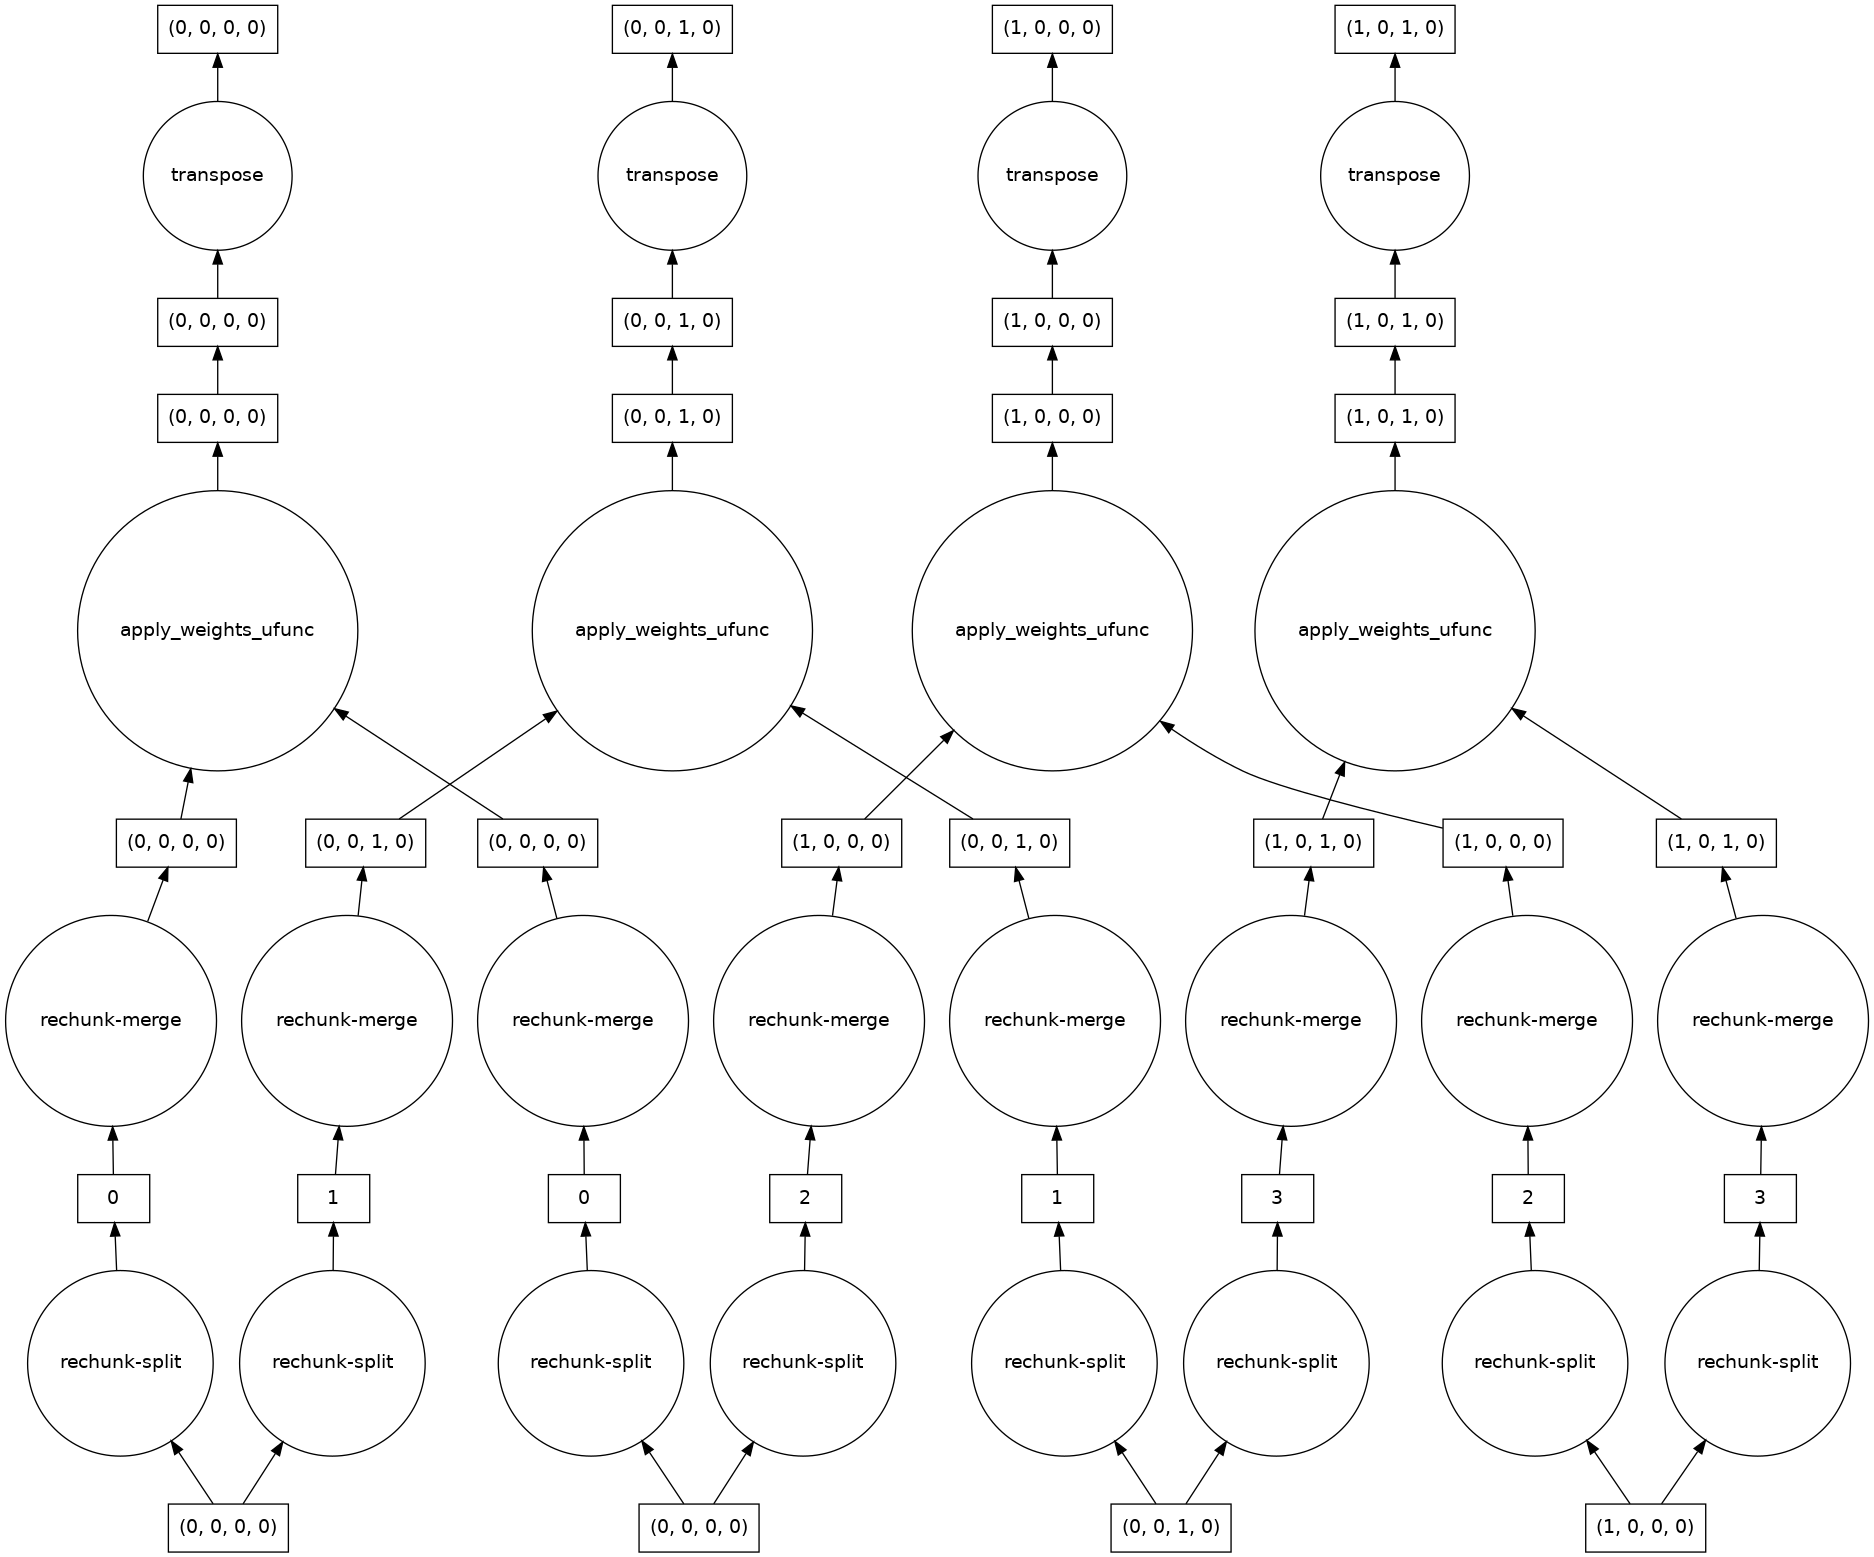

In [16]:
result = xr.apply_ufunc(
    apply_weights_ufunc, 
    vis_dask, weight_dask_time,
    dask="parallelized"
    )
result.data.visualize()

In [19]:
result.compute()

------------ START --------------
========== FIRST START ==========
<class 'numpy.ndarray'>
(1, 2, 2, 4)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(1, 2, 2, 4)
[[[[0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[1. 1. 1. 1.]
   [1. 1. 1. 1.]]]]
========= SECOND END ============
------------  END  --------------
------------ START --------------
========== FIRST START ==========
<class 'numpy.ndarray'>
(1, 2, 2, 4)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(1, 2, 2, 4)
[[[[0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[1. 1. 1. 1.]
   [1. 1. 1. 1.]]]]
========= SECOND END ============
------------  END  --------------
------------ START --------------
========== FIRST START ==========
<class 'numpy.ndarray'>
(1, 2, 2, 4)
========== FIRST END ============
========= SECOND START ==========
<class 'numpy.ndarray'>
(1, 2, 2, 4)
[[[[0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[1. 1. 1. 1.]
   [1. 1. 1. 1.]]]]
========= SECON

<xarray.DataArray (time: 2, baseline: 2, frequency: 4, pol: 4)> Size: 512B
array([[[[ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ]],

        [[ 2.4999046e+01-0.61038834j,  6.7443332e-05-0.00118741j,
          -5.8036228e-03-0.0012986j ,  2.2591185e+01-0.5300595j ],
         [ 2.5040884e+01-0.6130123j ,  6.4265958e-05-0.0011829j ,
          -5.8168592e-03-0.00129384j,  2.2631207e+01-0.5324733j ],
         [ 2.5082985e+01-0.6156461j ,  6.1092280e-05-0.00117837j,
          -5.8301669e-03-0.00128907j,  2.2671568e+01-0.5348987j ],
         [ 2.5125347e+01-0.61828965j,  5.7922338e-05-0.00117383j,
          -5.8435444e-03-0.00128428j,  2.2712265e+01-0.5373354j ]]],


       [[[ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ],
         [ 0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ,
           0.0000000e+00+0.j        ,  0.0000000e+00+0.j        ]],

        [[ 2.5046528e+01-0.61316466j, -3.5638007e-04-0.00116292j,
          -6.2457677e-03-0.0012674j ,  2.2634113e+01-0.532508j  ],
         [ 2.5088444e+01-0.6157959j , -3.6030103e-04-0.00115835j,
          -6.2597822e-03-0.00126258j,  2.2674210e+01-0.5349287j ],
         [ 2.5130627e+01-0.61843705j, -3.6422379e-04-0.00115377j,
          -6.2738727e-03-0.00125774j,  2.2714649e+01-0.5373609j ],
         [ 2.5173067e+01-0.62108797j, -3.6814815e-04-0.00114917j,
          -6.2880386e-03-0.00125289j,  2.2755421e+01-0.5398045j ]]]],
      dtype=complex64)
Coordinates:
  * time       (time) float64 16B 4.454e+09 4.454e+09
  * baseline   (baseline) int64 16B 0 1
  * frequency  (frequency) float64 32B 1.281e+08 1.282e+08 1.282e+08 1.282e+08
  * pol        (pol) <U2 32B 'XX' 'XY' 'YX' 'YY'

**Observations**

1. First array has two chunks on frequency, second again has two chunks but on time.
2. `apply_ufunc` rechunks each chunk. `vis_dask`'s chunks which chunked on frequency get rechunked on time. It gives 4 more chunks with chunked on time.
3. 'weight_dask_time`'s chunks which chunked on time get rechunked on frequency. It gives 4 more chunks with chunked on frequency.

Chunks for `vis_dask` and chunks for `weight_dask_time` are mapped correctly and passed to custom function.

```
vis_dask      weight_dask_time
---------     ---------------
(0,0,0,0)  -> (0,0,0,0)
(0,0,1,0)  -> (0,0,1,0)
(1,0,0,0)  -> (1,0,0,0)
(1,0,1,0)  -> (1,0,1,0)
```
4. So, custom function gets called four times

## `apply_ufunc` With Dataset

In [30]:
ds_dask = ds.chunk({"frequency": 2})
ds_dask.chunksizes

Frozen({'time': (2,), 'baseline': (2,), 'frequency': (2, 2), 'pol': (4,), 'spatial': (3,)})

In [46]:
def add_value_ufunc(arr):
    print("------------ START --------------")
    print(type(arr))
    print(arr.shape)
    print("------------ END --------------")
    return arr + 2

In [ ]:
result = xr.apply_ufunc(add_value_ufunc, ds_dask, dask="allowed")
result

------------ START --------------
<class 'dask.array.core.Array'>
(2, 2, 4, 4)
------------ END --------------
------------ START --------------
<class 'dask.array.core.Array'>
(2, 2, 4, 4)
------------ END --------------
------------ START --------------
<class 'dask.array.core.Array'>
(2, 2, 3)
------------ END --------------


<xarray.Dataset> Size: 972B
Dimensions:    (time: 2, baseline: 2, frequency: 4, pol: 4, spatial: 3)
Coordinates:
  * time       (time) float64 16B 4.454e+09 4.454e+09
  * baseline   (baseline) int64 16B 0 1
  * frequency  (frequency) float64 32B 1.281e+08 1.282e+08 1.282e+08 1.282e+08
  * pol        (pol) <U2 32B 'XX' 'XY' 'YX' 'YY'
  * spatial    (spatial) <U1 12B 'u' 'v' 'w'
Data variables:
    vis        (time, baseline, frequency, pol) complex64 512B dask.array<chunksize=(2, 2, 2, 4), meta=np.ndarray>
    weight     (time, baseline, frequency, pol) float32 256B dask.array<chunksize=(2, 2, 2, 4), meta=np.ndarray>
    uvw        (time, baseline, spatial) float64 96B dask.array<chunksize=(2, 2, 3), meta=np.ndarray>

**Observations**

1. Custom function is applied on each underlying dask array. 
2. custom function gets the dask array.
3. apply_ufunc creates back dataset with resulting dask arrays.

In [54]:
result = xr.apply_ufunc(add_value_ufunc, ds_dask, dask="parallelized")

------------ START --------------
<class 'numpy.ndarray'>
(1, 1, 1, 1)
------------ END --------------
------------ START --------------
<class 'numpy.ndarray'>
(1, 1, 1, 1)
------------ END --------------
------------ START --------------
<class 'numpy.ndarray'>
(1, 1, 1)
------------ END --------------


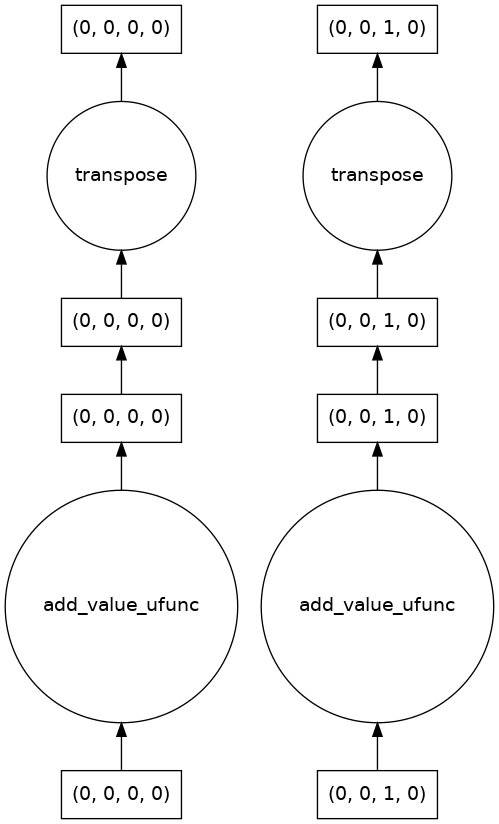

In [55]:
result.vis.data.visualize()

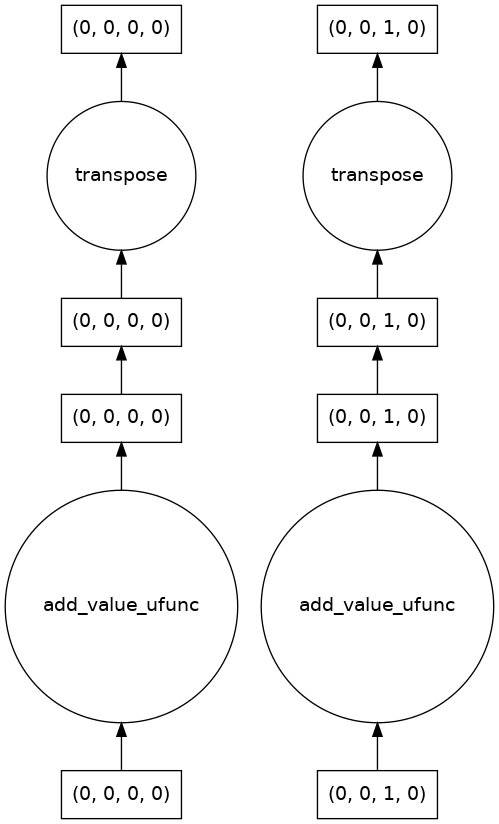

In [56]:
result.weight.data.visualize()

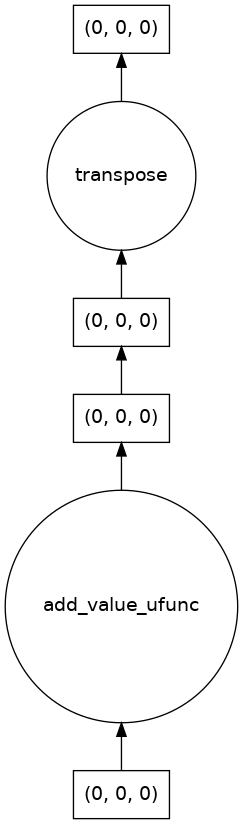

In [57]:
result.uvw.data.visualize()

**Observations**

1. Custom function is executed on each DataArray.
2. If custom function can't handle dask array, using `"dask=parallelized"`, `apply_ufunc` passes chunks to custom function as explained in previous sections. (**Passing xarrays with different dimensions**)
3. `apply_ufunc` creates back dataset.

### Dask Cluster (Optional)

In [21]:

use_dask = False

if use_dask:
    from distributed import Client, LocalCluster, performance_report
    if "local_cluster" not in globals():
        local_cluster = LocalCluster(
            n_workers=2, threads_per_worker=1, dashboard_address=":5050"
        )

    if "dask_client" not in globals():
        dask_client = local_cluster.get_client()

    print(local_cluster.dashboard_link)